In [2]:
import pandas as pd

In [3]:
pip install openpyxl


[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
df=pd.read_excel("online_retail_II.xlsx")

In [5]:
df.head(5)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [6]:
df.shape

(525461, 8)

In [7]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

In [8]:
df.columns=df.columns.str.lower()
df.columns=df.columns.str.replace(' ','_')

In [9]:
df.isnull().values.any()

np.True_

In [10]:
df.isnull().sum()

invoice             0
stockcode           0
description      2928
quantity            0
invoicedate         0
price               0
customer_id    107927
country             0
dtype: int64

In [11]:
df['customer_id'] = df['customer_id'].fillna('anonymous')

In [12]:
df['description'] = df['description'].fillna('Unknown item')


In [13]:
#Cancelled or returned invoices
df[df['invoice'].astype(str).str.startswith('C')].shape[0]


10206

In [14]:
# Canceled invoices
canceled_df = df[df['invoice'].astype(str).str.startswith('C')]

In [15]:
canceled_df.shape

(10206, 8)

In [16]:
# Non-canceled (valid) invoices
sales_df = df[~df['invoice'].astype(str).str.startswith('C')]

In [17]:
sales_df.shape

(515255, 8)

In [18]:
canceled_df[['quantity', 'price']].describe()


,quantity,price
count,10206.000000,10206.000000
mean,-20.911033,41.667525
std,208.261710,524.281828
min,-9360.000000,0.010000
25%,-6.000000,1.650000
50%,-2.000000,2.950000
75%,-1.000000,6.750000
max,1.000000,25111.090000


In [19]:
#Check for duplicates
df['invoice'].duplicated().sum()


np.int64(496645)

In [20]:
df['stockcode'].value_counts().head(50)


stockcode
85123A    3516
22423     2221
85099B    2057
21212     1933
21232     1843
20725     1620
84879     1458
84991     1400
21754     1386
20914     1276
21034     1232
21931     1220
21080     1209
22139     1203
21977     1196
22383     1192
22138     1180
20727     1179
82494L    1165
22470     1154
21843     1149
21755     1142
21733     1130
21231     1098
22386     1096
22411     1095
22384     1093
48138     1089
22469     1086
20685     1079
85099F    1074
22197     1073
20724     1070
22382     1059
22114     1051
22111     1048
21790     1044
47566     1041
21181     1038
22086     1007
85099C     992
20726      989
20728      988
82482      987
22112      958
84946      958
84836      947
22090      940
84970S     931
22149      924
Name: count, dtype: int64

In [21]:
df = df[~df['stockcode'].isin(['POST', 'BANK CHARGES', 'D', 'M'])]  # customize


In [22]:
df.shape

(523581, 8)

Description


In [23]:
#Convert to lowercase (for analysis consistency)
df['description'] = df['description'].str.lower()


In [24]:
#Remove whitespace
df['description']=df['description'].str.strip()

In [25]:
df.head(2)

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country
0,489434,85048,15cm christmas glass ball 20 lights,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,pink cherry lights,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom


Quantity

In [26]:
df[df['quantity']<0].shape[0]

11793

Invoic_date

In [27]:
df['invoicedate'] = pd.to_datetime(df['invoicedate'])


In [28]:
df['month'] = df['invoicedate'].dt.month
df['day_of_week'] = df['invoicedate'].dt.day_name()
df['hour'] = df['invoicedate'].dt.hour


In [29]:
df

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country,month,day_of_week,hour
0,489434,85048,15cm christmas glass ball 20 lights,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,12,Tuesday,7
1,489434,79323P,pink cherry lights,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,12,Tuesday,7
2,489434,79323W,white cherry lights,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,12,Tuesday,7
3,489434,22041,"record frame 7"" single size",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,12,Tuesday,7
4,489434,21232,strawberry ceramic trinket box,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,12,Tuesday,7
...,...,...,...,...,...,...,...,...,...,...,...
525456,538171,22271,feltcraft doll rosie,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom,12,Thursday,20
525457,538171,22750,feltcraft princess lola doll,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,12,Thursday,20
525458,538171,22751,feltcraft princess olivia doll,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,12,Thursday,20
525459,538171,20970,pink floral feltcraft shoulder bag,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,12,Thursday,20


Price

In [30]:
df[df['price'] <= 0]


,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country,month,day_of_week,hour
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,anonymous,United Kingdom,12,Tuesday,10
283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,anonymous,United Kingdom,12,Tuesday,10
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,anonymous,United Kingdom,12,Tuesday,10
470,489521,21646,unknown item,-50,2009-12-01 11:44:00,0.0,anonymous,United Kingdom,12,Tuesday,11
3114,489655,20683,unknown item,-44,2009-12-01 17:26:00,0.0,anonymous,United Kingdom,12,Tuesday,17
...,...,...,...,...,...,...,...,...,...,...,...
525231,538159,21324,unknown item,-18,2010-12-09 17:17:00,0.0,anonymous,United Kingdom,12,Thursday,17
525232,538158,20892,unknown item,-32,2010-12-09 17:17:00,0.0,anonymous,United Kingdom,12,Thursday,17
525233,538160,20956,unknown item,288,2010-12-09 17:18:00,0.0,anonymous,United Kingdom,12,Thursday,17
525234,538161,46000S,dotcom sales,-100,2010-12-09 17:25:00,0.0,anonymous,United Kingdom,12,Thursday,17


customer_id


In [31]:
df['customer_id'] = df['customer_id'].astype(str)


In [32]:
df['customer_id'].nunique()


4339

country


In [33]:
df['country'].value_counts()


country
United Kingdom          484857
EIRE                      9618
Germany                   7842
France                    5586
Netherlands               2694
Spain                     1235
Switzerland               1161
Portugal                  1074
Belgium                   1002
Channel Islands            904
Sweden                     867
Italy                      714
Australia                  647
Cyprus                     552
Greece                     516
Austria                    514
United Arab Emirates       427
Denmark                    417
Norway                     362
Finland                    346
Unspecified                309
USA                        239
Japan                      223
Poland                     193
Malta                      168
Lithuania                  154
Singapore                  117
RSA                        109
Bahrain                    107
Canada                      77
Thailand                    76
Israel                      74


In [34]:
df['country'] = df['country'].str.strip().str.lower()


In [35]:
df['total'] = df['quantity'] * df['price']


In [36]:
df

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country,month,day_of_week,hour,total
0,489434,85048,15cm christmas glass ball 20 lights,12,2009-12-01 07:45:00,6.95,13085.0,united kingdom,12,Tuesday,7,83.40
1,489434,79323P,pink cherry lights,12,2009-12-01 07:45:00,6.75,13085.0,united kingdom,12,Tuesday,7,81.00
2,489434,79323W,white cherry lights,12,2009-12-01 07:45:00,6.75,13085.0,united kingdom,12,Tuesday,7,81.00
3,489434,22041,"record frame 7"" single size",48,2009-12-01 07:45:00,2.10,13085.0,united kingdom,12,Tuesday,7,100.80
4,489434,21232,strawberry ceramic trinket box,24,2009-12-01 07:45:00,1.25,13085.0,united kingdom,12,Tuesday,7,30.00
...,...,...,...,...,...,...,...,...,...,...,...,...
525456,538171,22271,feltcraft doll rosie,2,2010-12-09 20:01:00,2.95,17530.0,united kingdom,12,Thursday,20,5.90
525457,538171,22750,feltcraft princess lola doll,1,2010-12-09 20:01:00,3.75,17530.0,united kingdom,12,Thursday,20,3.75
525458,538171,22751,feltcraft princess olivia doll,1,2010-12-09 20:01:00,3.75,17530.0,united kingdom,12,Thursday,20,3.75
525459,538171,20970,pink floral feltcraft shoulder bag,2,2010-12-09 20:01:00,3.75,17530.0,united kingdom,12,Thursday,20,7.50


In [37]:
print("Exact duplicate rows:", df.duplicated().sum())

Exact duplicate rows: 6859


In [38]:
df = df.drop_duplicates()

In [39]:
weird_codes = df['stockcode'].value_counts().head(20)
print(weird_codes)

stockcode
85123A    3470
22423     2211
85099B    2045
21212     1900
21232     1807
20725     1594
84879     1444
84991     1378
21754     1359
20914     1260
21931     1211
21080     1201
22139     1191
21977     1181
22383     1177
22138     1176
20727     1162
82494L    1157
21843     1146
21034     1140
Name: count, dtype: int64


In [40]:
df.to_csv('data_cleaned.csv', index=False)

RFM Analysis

In [41]:
df=df[df['quantity']>0]   

In [42]:
pd.Timedelta(days=1)

Timedelta('1 days 00:00:00')

RFM Analysis 

In [43]:
import datetime as dt

# Set reference date
today = df["invoicedate"].max() + pd.Timedelta(days=1)
today


Timestamp('2010-12-10 20:01:00')

In [44]:
df=df[df['customer_id']!='unknown']

In [45]:
rfm=df.groupby("customer_id").agg({"invoicedate":lambda x:(today-x.max()).days,
                                   "invoice":"nunique",
                                   "total":"sum"}).reset_index()

In [46]:
rfm

,customer_id,invoicedate,invoice,total
0,12346.0,165,11,372.86
1,12347.0,3,2,1323.32
2,12348.0,74,1,221.16
3,12349.0,43,2,2221.14
4,12351.0,11,1,300.93
...,...,...,...,...
4294,18284.0,67,1,461.68
4295,18285.0,296,1,427.00
4296,18286.0,112,2,1296.43
4297,18287.0,18,4,2345.71


In [47]:
rfm.columns=["customr_id","recency","frequency","monetary"]

In [48]:
rfm

,customr_id,recency,frequency,monetary
0,12346.0,165,11,372.86
1,12347.0,3,2,1323.32
2,12348.0,74,1,221.16
3,12349.0,43,2,2221.14
4,12351.0,11,1,300.93
...,...,...,...,...
4294,18284.0,67,1,461.68
4295,18285.0,296,1,427.00
4296,18286.0,112,2,1296.43
4297,18287.0,18,4,2345.71


In [49]:
#R_score-recency,F_score-frequency,M_score-monetary
#Lower Recency is better
rfm["R_score"]=pd.qcut(rfm["recency"],q=5,labels=[5,4,3,2,1])

#Frequency and Monetary needs to be higher
rfm["F_score"]=pd.qcut(rfm["frequency"].rank(method="first"),q=5,labels=[1,2,3,4,5])
rfm["M_score"]=pd.qcut(rfm["monetary"],q=5,labels=[1,2,3,4,5])


In [50]:
rfm["RFM_Segment"]=rfm["R_score"].astype(str)+rfm["F_score"].astype(str)+rfm["M_score"].astype(str)

rfm["RFM_Score"]=rfm[["R_score","F_score","M_score"]].astype(int).sum(axis=1)

In [51]:
def rfm_level(score):
    if score >= 12:
        return 'VIP'
    elif score >= 9:
        return 'Loyal'
    elif score >= 6:
        return 'Promising'
    else:
        return 'At Risk'

rfm["Segment"] = rfm["RFM_Score"].apply(rfm_level)


In [52]:
rfm.head()

,customr_id,recency,frequency,monetary,R_score,F_score,M_score,RFM_Segment,RFM_Score,Segment
0,12346.0,165,11,372.86,2,5,2,252,9,Loyal
1,12347.0,3,2,1323.32,5,2,4,524,11,Loyal
2,12348.0,74,1,221.16,2,1,1,211,4,At Risk
3,12349.0,43,2,2221.14,3,2,5,325,10,Loyal
4,12351.0,11,1,300.93,5,1,2,512,8,Promising


In [54]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
rfm_normalized=scaler.fit_transform(rfm[['recency','frequency','monetary']])


In [55]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(rfm_normalized)


In [56]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=4, random_state=42)
gmm_labels = gmm.fit_predict(rfm_normalized)


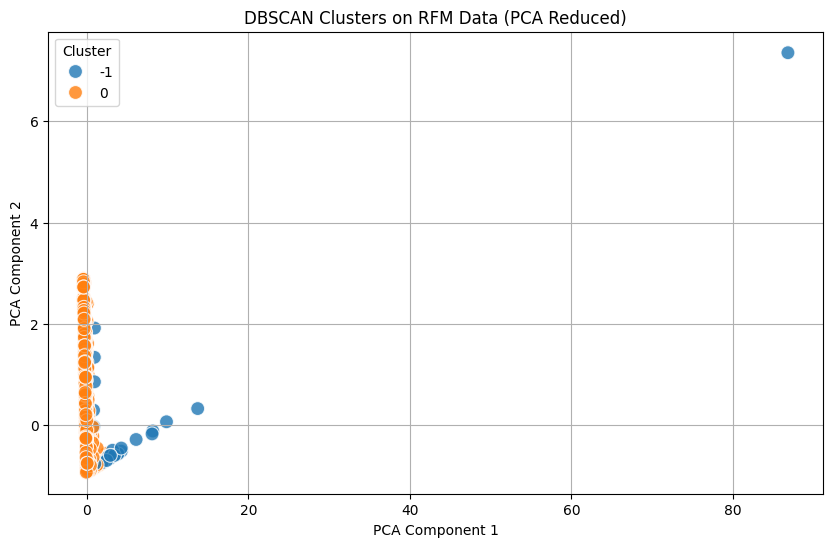

In [57]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Reduce RFM dimensions to 2D using PCA
pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_normalized)

# Step 2: Create a DataFrame for visualization
import pandas as pd

rfm_plot = pd.DataFrame(rfm_pca, columns=['PCA1', 'PCA2'])
rfm_plot['Cluster'] = dbscan_labels

# Step 3: Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=rfm_plot,
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    palette='tab10',
    legend='full',
    s=100,
    alpha=0.8
)
plt.title("DBSCAN Clusters on RFM Data (PCA Reduced)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title='Cluster')
plt.grid(True)
plt.show()


CLTV prediction(Customer Lifetime Value)

In [61]:
df = df[df['quantity'] > 0]
df = df[df['price'] > 0]
df['invoicedate'] = pd.to_datetime(df['invoicedate'])



In [ ]:
df

In [63]:
from lifetimes.utils import summary_data_from_transaction_data

summary = summary_data_from_transaction_data(
    df, 
    customer_id_col='customer_id', 
    datetime_col='invoicedate',
    monetary_value_col='total_price',  # Needed for Gamma-Gamma model
    observation_period_end=df['invoicedate'].max()
)

summary.head()

,frequency,recency,T,monetary_value
customer_id,,,,
12346.0,6.0,196.0,360.0,47.143333
12347.0,1.0,37.0,39.0,711.790000
12348.0,0.0,0.0,73.0,0.000000
12349.0,1.0,182.0,224.0,1152.620000
12351.0,0.0,0.0,10.0,0.000000


In [65]:
summary = summary[summary["monetary_value"] > 0]


In [66]:
from lifetimes import BetaGeoFitter

bgf = BetaGeoFitter(penalizer_coef=0.01)
bgf.fit(summary['frequency'], summary['recency'], summary['T'])

# Predict future purchases in next 6 months (180 days)
summary['pred_purchases_6m'] = bgf.conditional_expected_number_of_purchases_up_to_time(
    180, summary['frequency'], summary['recency'], summary['T']
)


In [67]:
from lifetimes import GammaGammaFitter

# Remove customers with 0 monetary value
summary = summary[summary['monetary_value'] > 0]

ggf = GammaGammaFitter(penalizer_coef=0.01)
ggf.fit(summary['frequency'], summary['monetary_value'])

# Predict avg. order value
summary['expected_avg_value'] = ggf.conditional_expected_average_profit(
    summary['frequency'], summary['monetary_value']
)


In [68]:
summary['cltv_6m'] = ggf.customer_lifetime_value(
    bgf, 
    summary['frequency'], 
    summary['recency'], 
    summary['T'], 
    summary['monetary_value'],
    time=6,     # in months
    freq='D',   # frequency unit of time
    discount_rate=0.01  # optional
)

summary = summary.reset_index()
summary[['customer_id', 'cltv_6m']].sort_values(by='cltv_6m', ascending=False).head(10)


,customer_id,cltv_6m
2810,anonymous,494114.642222
2745,18102.0,136578.028559
1073,14646.0,95171.120763
824,14156.0,72459.886851
1201,14911.0,54993.411553
598,13694.0,50826.370814
2045,16684.0,33302.853696
2079,16754.0,33145.483019
2454,17511.0,33081.317677
1267,15061.0,31563.395728


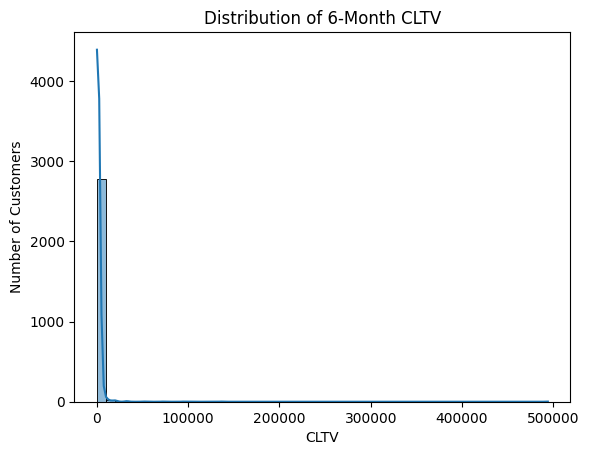

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(summary['cltv_6m'], bins=50, kde=True)
plt.title("Distribution of 6-Month CLTV")
plt.xlabel("CLTV")
plt.ylabel("Number of Customers")
plt.show()
